In [ ]:
!nvidia-smi

!pip install -U -q ultralytics opencv-python-headless pycocotools pyyaml

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import shutil
import glob
import torch
from ultralytics import YOLO

print("torch cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Wed May  6 06:34:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             53W /  400W |    2454MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

2번 셀: 내 Drive dataset 경로 지정

In [ ]:
from pathlib import Path
import shutil

DRIVE_DATASET = Path("/content/drive/MyDrive/hand_eye_view_train_1280")

print("Exists:", DRIVE_DATASET.exists())
print("Path:", DRIVE_DATASET)

for p in DRIVE_DATASET.iterdir():
    print(p)

COCO_DIR = Path("/content/coco_dataset_1280")

if COCO_DIR.exists():
    shutil.rmtree(COCO_DIR)

shutil.copytree(DRIVE_DATASET, COCO_DIR)

print("Copied dataset to:", COCO_DIR)

json_files = list(COCO_DIR.rglob("*.json"))
print("JSON files:")
for j in json_files:
    print(j)

Exists: True
Path: /content/drive/MyDrive/hand_eye_view_train_1280
/content/drive/MyDrive/hand_eye_view_train_1280/README.roboflow.txt
/content/drive/MyDrive/hand_eye_view_train_1280/README.dataset.txt
/content/drive/MyDrive/hand_eye_view_train_1280/valid
/content/drive/MyDrive/hand_eye_view_train_1280/train
/content/drive/MyDrive/hand_eye_view_train_1280/test
Copied dataset to: /content/coco_dataset_1280
JSON files:
/content/coco_dataset_1280/train/_annotations.coco.json
/content/coco_dataset_1280/test/_annotations.coco.json
/content/coco_dataset_1280/valid/_annotations.coco.json


3번 셀: Drive dataset을 colab 로컬로 복사

In [ ]:
from pathlib import Path
import shutil

SRC_DRIVE = DRIVE_DATASET
COCO_DIR = Path("/content/coco_dataset_1280")

if COCO_DIR.exists():
    shutil.rmtree(COCO_DIR)

shutil.copytree(SRC_DRIVE, COCO_DIR)

print("Copied dataset to:", COCO_DIR)

# COCO annotation json 확인
json_files = list(COCO_DIR.rglob("*.json"))
print("JSON files:")
for j in json_files:
    print(j)

Copied dataset to: /content/coco_dataset_1280
JSON files:
/content/coco_dataset_1280/train/_annotations.coco.json
/content/coco_dataset_1280/test/_annotations.coco.json
/content/coco_dataset_1280/valid/_annotations.coco.json


4번 셀: COCO segmentation -> YOLO segmentation 변환

In [ ]:
from pathlib import Path
import json
import shutil
import yaml
import cv2
import numpy as np
from pycocotools import mask as mask_utils
from PIL import Image

SRC = Path("/content/coco_dataset_1280")
DST = Path("/content/speed_stack_yolo_seg_1280_medium")

if DST.exists():
    shutil.rmtree(DST)

# Roboflow는 보통 train / valid / test를 사용함
possible_splits = ["train", "valid", "val", "test"]

# annotation json 찾기
split_jsons = {}
for split in possible_splits:
    ann_path = SRC / split / "_annotations.coco.json"
    if ann_path.exists():
        split_jsons[split] = ann_path

print("Found splits:")
for k, v in split_jsons.items():
    print(k, "->", v)

assert "train" in split_jsons, "train/_annotations.coco.json을 찾지 못했습니다."
assert ("valid" in split_jsons) or ("val" in split_jsons), "valid 또는 val annotation을 찾지 못했습니다."

# class 정보 읽기
with open(split_jsons["train"], "r") as f:
    train_data = json.load(f)

categories = sorted(train_data["categories"], key=lambda c: c["id"])
cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}
names = [c["name"] for c in categories]

print("Classes:", names)


def find_image_path(split_dir: Path, file_name: str):
    """
    COCO json의 file_name과 실제 파일 위치가 조금 다를 수 있어서 보수적으로 찾음.
    """
    p1 = split_dir / file_name
    if p1.exists():
        return p1

    p2 = split_dir / Path(file_name).name
    if p2.exists():
        return p2

    matches = list(split_dir.rglob(Path(file_name).name))
    if len(matches) > 0:
        return matches[0]

    return None


def polygon_area(poly):
    pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
    return abs(cv2.contourArea(pts))


def coco_seg_to_polygons(segmentation, width, height):
    """
    COCO segmentation을 polygon list로 변환.
    - polygon format: [[x1,y1,x2,y2,...], ...]
    - RLE format도 가능하면 contour로 변환
    """
    polygons = []

    # 1) Polygon format
    if isinstance(segmentation, list):
        for poly in segmentation:
            if isinstance(poly, list) and len(poly) >= 6:
                polygons.append(poly)
        return polygons

    # 2) RLE format
    if isinstance(segmentation, dict):
        rle = segmentation

        # uncompressed RLE인 경우
        if isinstance(rle.get("counts"), list):
            rle = mask_utils.frPyObjects(rle, height, width)

        mask = mask_utils.decode(rle)

        if mask.ndim == 3:
            mask = np.any(mask, axis=2).astype(np.uint8)
        else:
            mask = mask.astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if len(cnt) >= 3:
                poly = cnt.reshape(-1, 2).astype(float).flatten().tolist()
                if len(poly) >= 6:
                    polygons.append(poly)

        return polygons

    return polygons


def normalize_polygon(poly, width, height):
    """
    YOLO segmentation format:
    class x1 y1 x2 y2 x3 y3 ...
    모든 좌표는 0~1 normalized 값.
    """
    values = []

    for x, y in zip(poly[0::2], poly[1::2]):
        x = max(0.0, min(1.0, float(x) / float(width)))
        y = max(0.0, min(1.0, float(y) / float(height)))
        values.extend([x, y])

    return values


for split, ann_path in split_jsons.items():
    print(f"\nConverting split: {split}")

    split_dir = SRC / split
    out_img_dir = DST / "images" / split
    out_label_dir = DST / "labels" / split

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_label_dir.mkdir(parents=True, exist_ok=True)

    with open(ann_path, "r") as f:
        data = json.load(f)

    images = {img["id"]: img for img in data["images"]}
    anns_by_image = {img_id: [] for img_id in images.keys()}

    for ann in data["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    converted_images = 0
    converted_objects = 0
    skipped_objects = 0

    for img_id, img in images.items():
        file_name = Path(img["file_name"]).name

        src_img_path = find_image_path(split_dir, img["file_name"])
        if src_img_path is None:
            print("Image not found, skip:", img["file_name"])
            continue

        dst_img_path = out_img_dir / file_name
        shutil.copy2(src_img_path, dst_img_path)

        width = img.get("width", None)
        height = img.get("height", None)

        if width is None or height is None:
            with Image.open(src_img_path) as im:
                width, height = im.size

        label_lines = []

        for ann in anns_by_image.get(img_id, []):
            category_id = ann["category_id"]

            if category_id not in cat_id_to_idx:
                skipped_objects += 1
                continue

            cls_idx = cat_id_to_idx[category_id]
            segmentation = ann.get("segmentation", [])

            polygons = coco_seg_to_polygons(segmentation, width, height)

            if len(polygons) == 0:
                skipped_objects += 1
                continue

            # 한 객체에 polygon이 여러 개 있으면 가장 큰 polygon만 사용
            # 컵 segmentation에서는 보통 polygon 하나라서 문제 없음
            polygons = sorted(polygons, key=polygon_area, reverse=True)
            poly = polygons[0]

            if len(poly) < 6:
                skipped_objects += 1
                continue

            norm_coords = normalize_polygon(poly, width, height)

            if len(norm_coords) < 6:
                skipped_objects += 1
                continue

            line = str(cls_idx) + " " + " ".join(f"{v:.6f}" for v in norm_coords)
            label_lines.append(line)
            converted_objects += 1

        label_path = out_label_dir / (Path(file_name).stem + ".txt")
        label_path.write_text("\n".join(label_lines))

        converted_images += 1

    print("converted images:", converted_images)
    print("converted objects:", converted_objects)
    print("skipped objects:", skipped_objects)

# data.yaml 생성
val_split = "valid" if "valid" in split_jsons else "val"

yaml_data = {
    "path": str(DST),
    "train": "images/train",
    "val": f"images/{val_split}",
    "names": names,
}

if "test" in split_jsons:
    yaml_data["test"] = "images/test"

with open(DST / "data.yaml", "w") as f:
    yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

print("\nYOLO-seg dataset created at:", DST)
print("\ndata.yaml:")
print((DST / "data.yaml").read_text())

Found splits:
train -> /content/coco_dataset_1280/train/_annotations.coco.json
valid -> /content/coco_dataset_1280/valid/_annotations.coco.json
test -> /content/coco_dataset_1280/test/_annotations.coco.json
Classes: ['hand-eye-view-train', 'cup']

Converting split: train
Image not found, skip: capture_20260504_153012_228_png.rf.ff7849136b94069d62b2b3d3c3032cac.jpg
converted images: 138
converted objects: 625
skipped objects: 0

Converting split: valid
converted images: 40
converted objects: 159
skipped objects: 0

Converting split: test
Image not found, skip: capture_20260504_152905_214_png.rf.0f6f3d87ae8fcfa7c7b17c66b5616af7.jpg
converted images: 19
converted objects: 72
skipped objects: 0

YOLO-seg dataset created at: /content/speed_stack_yolo_seg_1280_medium

data.yaml:
path: /content/speed_stack_yolo_seg_1280_medium
train: images/train
val: images/valid
names:
- hand-eye-view-train
- cup
test: images/test



5번 셀: 변환이 제대로 됐는지 확인

In [ ]:
import glob
from pathlib import Path

label_files = glob.glob("/content/speed_stack_yolo_seg_1280/labels/train/*.txt")
print("label file count:", len(label_files))

non_empty = []
for lf in label_files:
    if Path(lf).read_text().strip():
        non_empty.append(lf)

print("non-empty label count:", len(non_empty))

sample_label = non_empty[0]
print("sample label:", sample_label)

lines = Path(sample_label).read_text().strip().splitlines()
print("first line:")
print(lines[0])
print("number of values:", len(lines[0].split()))

label file count: 139
non-empty label count: 139
sample label: /content/speed_stack_yolo_seg_1280/labels/train/capture_20260504_152946_221_png.rf.e71a9e473c363a33c098f47e501241aa.txt
first line:
1 0.472656 0.498437 0.471875 0.500000 0.466406 0.500000 0.465625 0.501563 0.464062 0.501563 0.463281 0.503125 0.461719 0.503125 0.460938 0.504687 0.460156 0.504687 0.459375 0.506250 0.458594 0.506250 0.457813 0.507812 0.456250 0.507812 0.455469 0.509375 0.454688 0.509375 0.453125 0.512500 0.451562 0.512500 0.450781 0.514062 0.450000 0.514062 0.448437 0.517188 0.447656 0.517188 0.447656 0.518750 0.446875 0.520312 0.446094 0.520312 0.443750 0.525000 0.442969 0.525000 0.441406 0.528125 0.441406 0.529687 0.437500 0.537500 0.436719 0.537500 0.435937 0.539062 0.435937 0.542188 0.435156 0.543750 0.435156 0.545312 0.434375 0.546875 0.434375 0.548438 0.433594 0.550000 0.432812 0.550000 0.432812 0.551562 0.432031 0.553125 0.432031 0.554688 0.431250 0.556250 0.431250 0.557813 0.430469 0.559375 0.430469 0.

6번 셀: YOLOv26-seg 학습

In [ ]:
from ultralytics import YOLO
import torch

DATA_YAML = "/content/speed_stack_yolo_seg_1280/data.yaml"

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

model = YOLO("yolo26m-seg.pt")

results = model.train(
    data=DATA_YAML,
    task="segment",

    # 성능 우선
    epochs=200,
    imgsz=1280,
    batch=0.70,          # A100 GPU 메모리의 약 70%를 쓰는 자동 batch
    patience=50,

    # YOLO26 / 학습 안정성
    optimizer="auto",
    cos_lr=True,
    warmup_epochs=5.0,
    weight_decay=0.0005,

    # Segmentation mask 품질
    overlap_mask=True,
    mask_ratio=2,

    # Speed Stack cup에 맞춘 augmentation
    hsv_h=0.015,
    hsv_s=0.45,
    hsv_v=0.30,
    degrees=5.0,
    translate=0.05,
    scale=0.30,
    shear=0.0,
    perspective=0.0003,
    flipud=0.0,
    fliplr=0.5,

    # Mosaic은 너무 강하면 로봇팔 실제 시점과 달라질 수 있으므로 약하게
    mosaic=0.30,
    close_mosaic=20,
    mixup=0.0,
    copy_paste=0.0,

    # 실행 환경
    device=DEVICE,
    workers=8,
    amp=True,
    cache="ram",
    plots=True,
    save=True,
    save_period=10,

    project="/content/runs",
    name="speed_stack_yolo26m_seg_1280_a100",
    exist_ok=True
)

device: 0
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=0.7, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/speed_stack_yolo_seg_1280/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=2, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=speed_stack_yolo26m_seg_1280_a100, nbs=64, nms=False, opset=Non

7번 셀: validation 평가

In [ ]:
from ultralytics import YOLO

BEST_MODEL = "/content/runs/speed_stack_yolo26m_seg_1280_a100/weights/best.pt"

model = YOLO(BEST_MODEL)

metrics = model.val(
    data="/content/speed_stack_yolo_seg_1280/data.yaml",
    task="segment",
    imgsz=1280,
    batch=8,
    device=DEVICE,
    plots=True
)

print("box mAP50-95:", metrics.box.map)
print("mask mAP50-95:", metrics.seg.map)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26m-seg summary (fused): 149 layers, 23,509,010 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1882.3±530.1 MB/s, size: 50.6 KB)
val: Scanning /content/speed_stack_yolo_seg_1280/labels/valid.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 15.3Mit/s 0.0s
val: /content/speed_stack_yolo_seg_1280/images/valid/capture_20260504_152524_186_png.rf.c919117f65a971eca920253c13f99995.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.5it/s 1.4s
                   all         40        158      0.938      0.861      0.952      0.896      0.951      0.854      0.889      0.855
                   cup         40        158      0.938      0.861      0.952      0.896      0.951      0.854      0.889      0

8번 셀: 테스트 이미지 예측

test image count: 20
source: /content/speed_stack_yolo_seg_1280/images/test/capture_20260504_152039_102_png.rf.142fe183585c8213eb0b1cc562929f75.jpg

image 1/1 /content/speed_stack_yolo_seg_1280/images/test/capture_20260504_152039_102_png.rf.142fe183585c8213eb0b1cc562929f75.jpg: 640x1280 3 cups, 86.5ms
Speed: 2.8ms preprocess, 86.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 1280)
Results saved to /content/preds/speed_stack_yolo26m_1280_test
저장 위치: /content/preds/speed_stack_yolo26m_1280_test


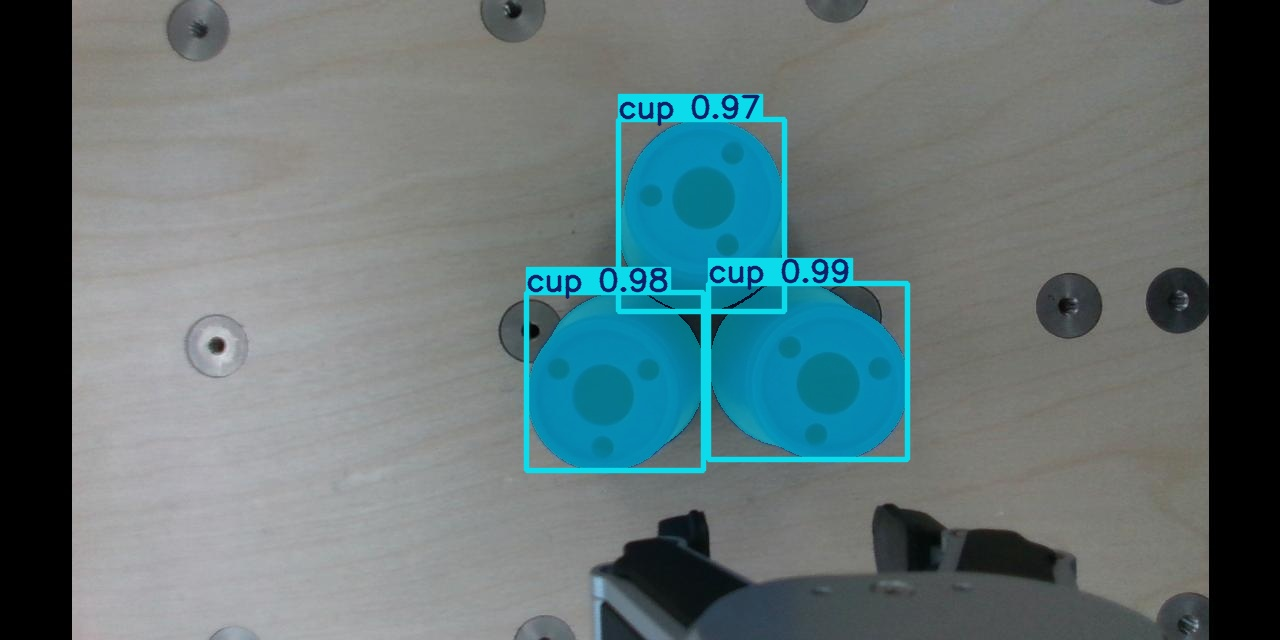

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import glob
from IPython.display import Image, display

BEST_MODEL = "/content/runs/speed_stack_yolo26m_seg_1280_a100/weights/best.pt"
model = YOLO(BEST_MODEL)

test_images = glob.glob("/content/speed_stack_yolo_seg_1280/images/test/*")

if len(test_images) == 0:
    test_images = glob.glob("/content/speed_stack_yolo_seg_1280/images/valid/*")

print("test image count:", len(test_images))

source_img = test_images[0]
print("source:", source_img)

results = model.predict(
    source=source_img,
    task="segment",
    imgsz=1280,
    conf=0.25,
    iou=0.7,
    device=DEVICE,
    save=True,
    retina_masks=True,
    project="/content/preds",
    name="speed_stack_yolo26m_1280_test",
    exist_ok=True
)

print("저장 위치:", results[0].save_dir)

pred_dir = Path("/content/preds/speed_stack_yolo26m_1280_test")
pred_images = list(pred_dir.glob("*"))

for p in pred_images[:5]:
    display(Image(filename=str(p)))

9번: 학습된 모델을 Drive에 저장

In [ ]:
from pathlib import Path
import shutil

SAVE_DIR = Path("/content/drive/MyDrive/speed_stack_yolo_seg_result")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

src_model = Path("/content/runs/speed_stack_yolo26m_seg_1280_a100/weights/best.pt")
dst_model = SAVE_DIR / "speed_stack_yolo26m_seg_1280_a100_best.pt"

shutil.copy2(src_model, dst_model)

print("Saved to:", dst_model)

Saved to: /content/drive/MyDrive/speed_stack_yolo_seg_result/speed_stack_yolo26m_seg_1280_a100_best.pt


1, 모델 로드 + 입력 이미지 지정

In [ ]:
!pip install -U -q ultralytics opencv-python-headless

from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from pathlib import Path
import torch
import cv2
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

# 1280으로 학습한 YOLO26 모델 경로로 수정
MODEL_PATH = "/content/runs/speed_stack_yolo26m_seg_1280_a100/weights/best.pt"

# 1280 dataset 또는 테스트하고 싶은 이미지 경로로 수정
INPUT_IMAGE = "/content/drive/MyDrive/hand_eye_view_train_1280/test/1.jpg"

print("model exists:", Path(MODEL_PATH).exists())
print("image exists:", Path(INPUT_IMAGE).exists())

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

model = YOLO(MODEL_PATH)
print("class names:", model.names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
model exists: True
image exists: True
device: 0
class names: {0: 'hand-eye-view-train', 1: 'cup'}


2. 한 장의 이미지에 대해 segmentation 실행


image 1/1 /content/drive/MyDrive/hand_eye_view_train_1280/test/1.jpg: 640x1280 4 cups, 14.2ms
Speed: 3.4ms preprocess, 14.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 1280)
Results saved to /content/preds/speed_stack_yolo26_1280_single
검출 개수: 4
저장 위치: /content/preds/speed_stack_yolo26_1280_single


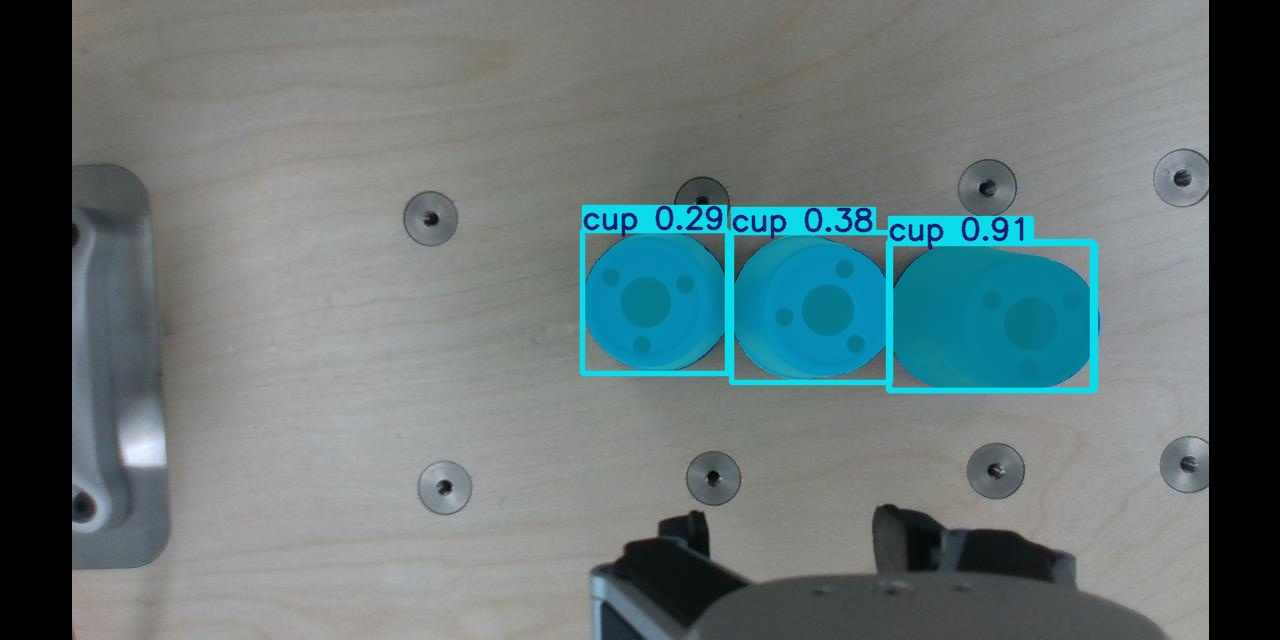

In [ ]:
results = model.predict(
    source=INPUT_IMAGE,
    task="segment",
    imgsz=1280,
    conf=0.25,
    device=DEVICE,
    save=True,
    project="/content/preds",
    name="speed_stack_yolo26_1280_single",
    exist_ok=True,
    retina_masks=True
)

result = results[0]

print("검출 개수:", 0 if result.boxes is None else len(result.boxes))
print("저장 위치:", result.save_dir)

pred_img_path = list(Path("/content/preds/speed_stack_yolo26_1280_single").glob("*"))[0]
display(Image(filename=str(pred_img_path)))

3. mask, bbox, confidence, 중심점까지 추출하기

```
# 코드로 형식 지정됨
```



In [ ]:
import cv2
import numpy as np
from pathlib import Path
import pandas as pd

SAVE_MASK_DIR = Path("/content/cup_masks_yolo26_1280")
SAVE_MASK_DIR.mkdir(parents=True, exist_ok=True)

img = cv2.imread(INPUT_IMAGE)
assert img is not None, "이미지를 읽지 못했습니다. INPUT_IMAGE 경로를 확인하세요."

H, W = img.shape[:2]

result = results[0]

if result.masks is None:
    print("검출된 segmentation mask가 없습니다.")
else:
    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    info_list = []

    for i, mask in enumerate(masks):
        mask_bin = (mask > 0.5).astype(np.uint8)

        if mask_bin.shape != (H, W):
            mask_bin = cv2.resize(mask_bin, (W, H), interpolation=cv2.INTER_NEAREST)

        area = int(mask_bin.sum())

        M = cv2.moments(mask_bin)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = -1, -1

        x1, y1, x2, y2 = boxes[i].astype(int)
        cls_id = int(classes[i])
        cls_name = model.names[cls_id]
        conf = float(confs[i])

        mask_img = (mask_bin * 255).astype(np.uint8)
        mask_path = SAVE_MASK_DIR / f"cup_{i:02d}_mask.png"
        cv2.imwrite(str(mask_path), mask_img)

        info_list.append({
            "id": i,
            "class_id": cls_id,
            "class_name": cls_name,
            "confidence": round(conf, 4),
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "center_x": cx,
            "center_y": cy,
            "mask_area_px": area,
            "mask_path": str(mask_path)
        })

    df = pd.DataFrame(info_list)
    display(df)

    print("mask 저장 폴더:", SAVE_MASK_DIR)

,id,class_id,class_name,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2,center_x,center_y,mask_area_px,mask_path
0,0,1,cup,0.9054,888,241,1092,390,989,319,25341,/content/cup_masks_yolo26_1280/cup_00_mask.png
1,1,1,cup,0.3768,731,232,890,382,810,307,18662,/content/cup_masks_yolo26_1280/cup_01_mask.png
2,2,1,cup,0.3502,889,243,1095,390,990,319,25374,/content/cup_masks_yolo26_1280/cup_02_mask.png
3,3,1,cup,0.2857,582,230,727,373,656,300,16246,/content/cup_masks_yolo26_1280/cup_03_mask.png


mask 저장 폴더: /content/cup_masks_yolo26_1280


4. segmentation 결과를 직접 overlay해서 저장하기

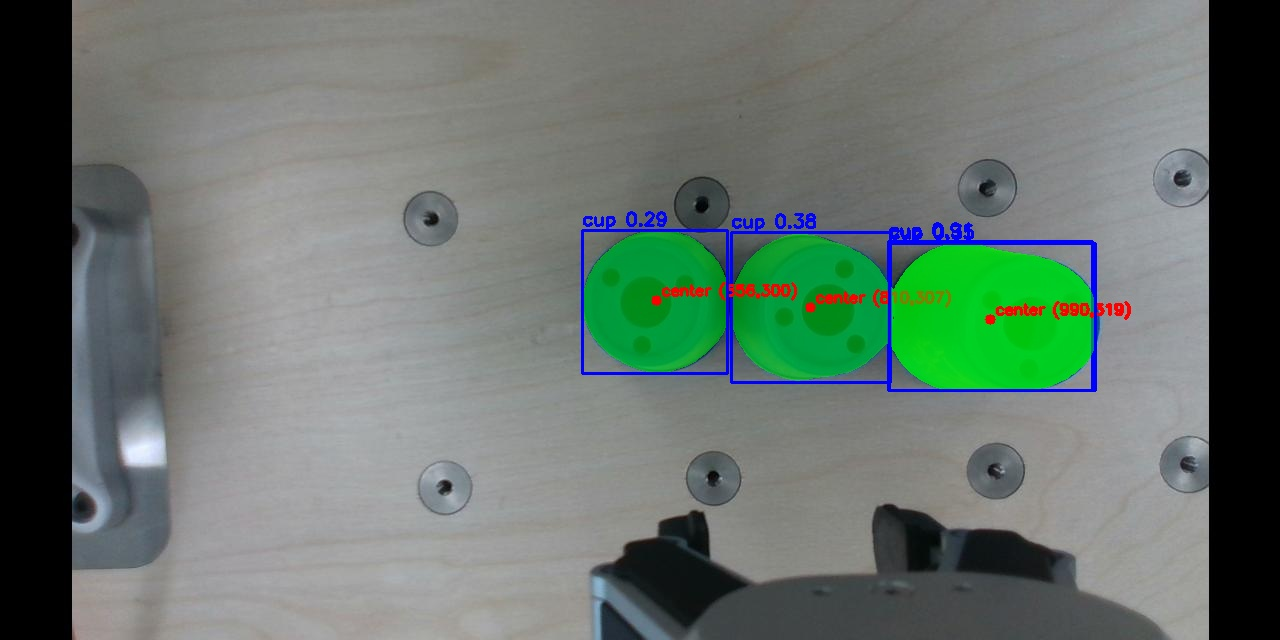

saved: /content/segmentation_overlay_yolo26_1280.jpg


In [ ]:
overlay = img.copy()

if result.masks is not None:
    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for i, mask in enumerate(masks):
        mask_bin = (mask > 0.5).astype(np.uint8)

        if mask_bin.shape != (H, W):
            mask_bin = cv2.resize(mask_bin, (W, H), interpolation=cv2.INTER_NEAREST)

        color = np.array([0, 255, 0], dtype=np.uint8)
        overlay[mask_bin == 1] = overlay[mask_bin == 1] * 0.5 + color * 0.5

        x1, y1, x2, y2 = boxes[i].astype(int)
        cls_id = int(classes[i])
        cls_name = model.names[cls_id]
        conf = float(confs[i])

        M = cv2.moments(mask_bin)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.circle(overlay, (cx, cy), 5, (0, 0, 255), -1)
            cv2.putText(
                overlay,
                f"center ({cx},{cy})",
                (cx + 5, cy - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),
                2
            )

        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            overlay,
            f"{cls_name} {conf:.2f}",
            (x1, max(y1 - 5, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

OUT_PATH = "/content/segmentation_overlay_yolo26_1280.jpg"
cv2.imwrite(OUT_PATH, overlay)

display(Image(filename=OUT_PATH))
print("saved:", OUT_PATH)

*5*. 폴더 안의 여러 이미지 한 번에 segmentation 하기

In [ ]:
INPUT_DIR = "/content/drive/MyDrive/hand_eye_view_train_1280/valid/"

results = model.predict(
    source=INPUT_DIR,
    task="segment",
    imgsz=1280,
    conf=0.25,
    device=DEVICE,
    save=True,
    project="/content/preds",
    name="speed_stack_yolo26_1280_folder",
    exist_ok=True,
    retina_masks=True
)

print("결과 저장 위치:", results[0].save_dir)


image 1/40 /content/drive/MyDrive/hand_eye_view_train_1280/valid/capture_20260504_151623_029_png.rf.98d028f8585ea07d6c41a1a02bb86264.jpg: 640x1280 1 cup, 14.4ms
image 2/40 /content/drive/MyDrive/hand_eye_view_train_1280/valid/capture_20260504_151724_042_png.rf.75196133a120899dd21cb8f826c00969.jpg: 640x1280 2 cups, 13.5ms
image 3/40 /content/drive/MyDrive/hand_eye_view_train_1280/valid/capture_20260504_151726_043_png.rf.6831e27791c2b16e13cc0d34659f5be3.jpg: 640x1280 1 cup, 13.9ms
image 4/40 /content/drive/MyDrive/hand_eye_view_train_1280/valid/capture_20260504_151727_044_png.rf.53e821433339e80ffb8daecaac2a638b.jpg: 640x1280 1 cup, 14.0ms
image 5/40 /content/drive/MyDrive/hand_eye_view_train_1280/valid/capture_20260504_151732_045_png.rf.35b2ba50a17128c8377c06f2db7190d0.jpg: 640x1280 2 cups, 13.4ms
image 6/40 /content/drive/MyDrive/hand_eye_view_train_1280/valid/capture_20260504_151745_049_png.rf.497f7e09c75c445bc491de4bed162271.jpg: 640x1280 2 cups, 13.3ms
image 7/40 /content/drive/MyDr

결과 몇 장 확인

result images: 40


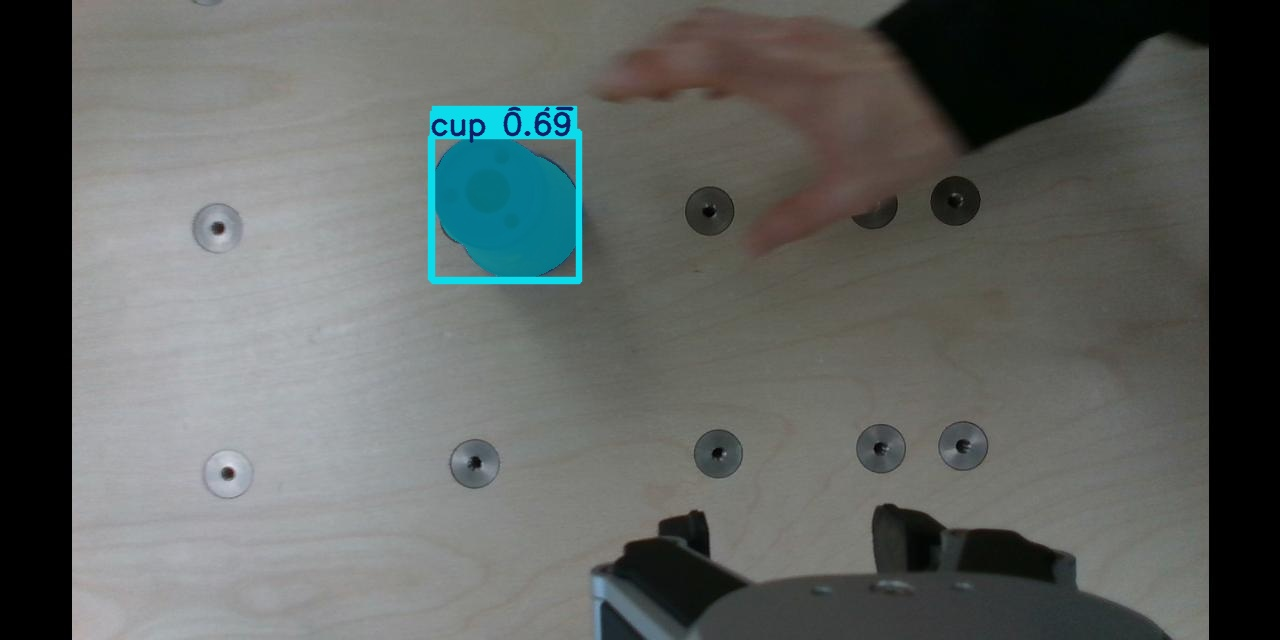

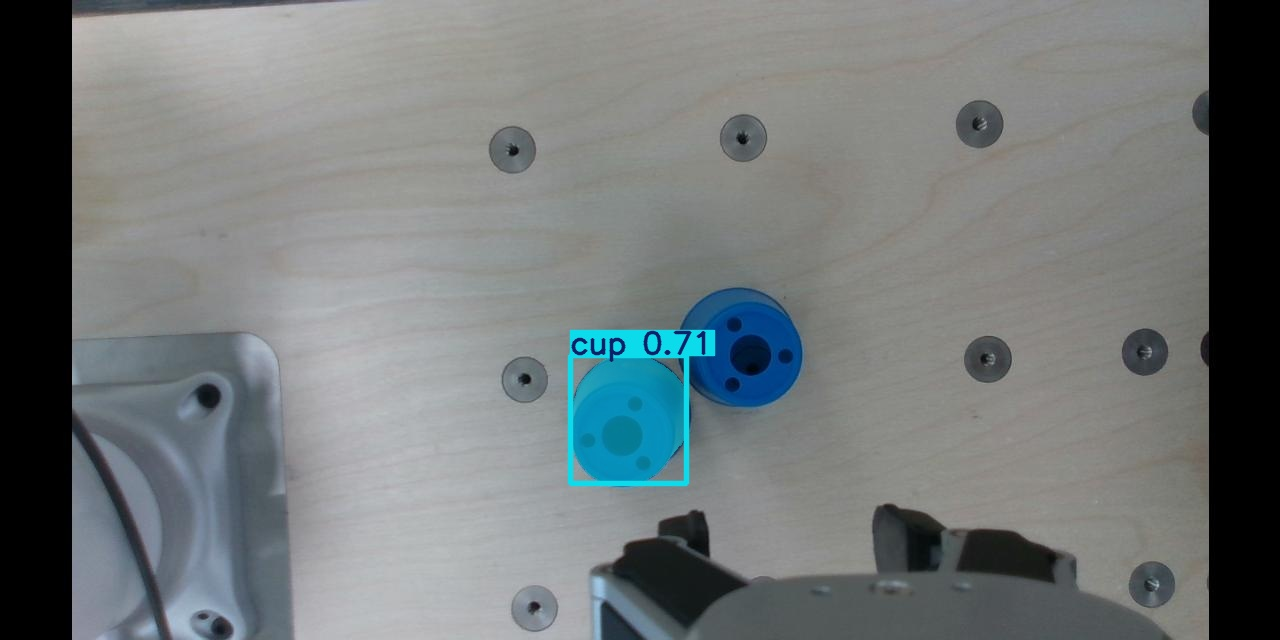

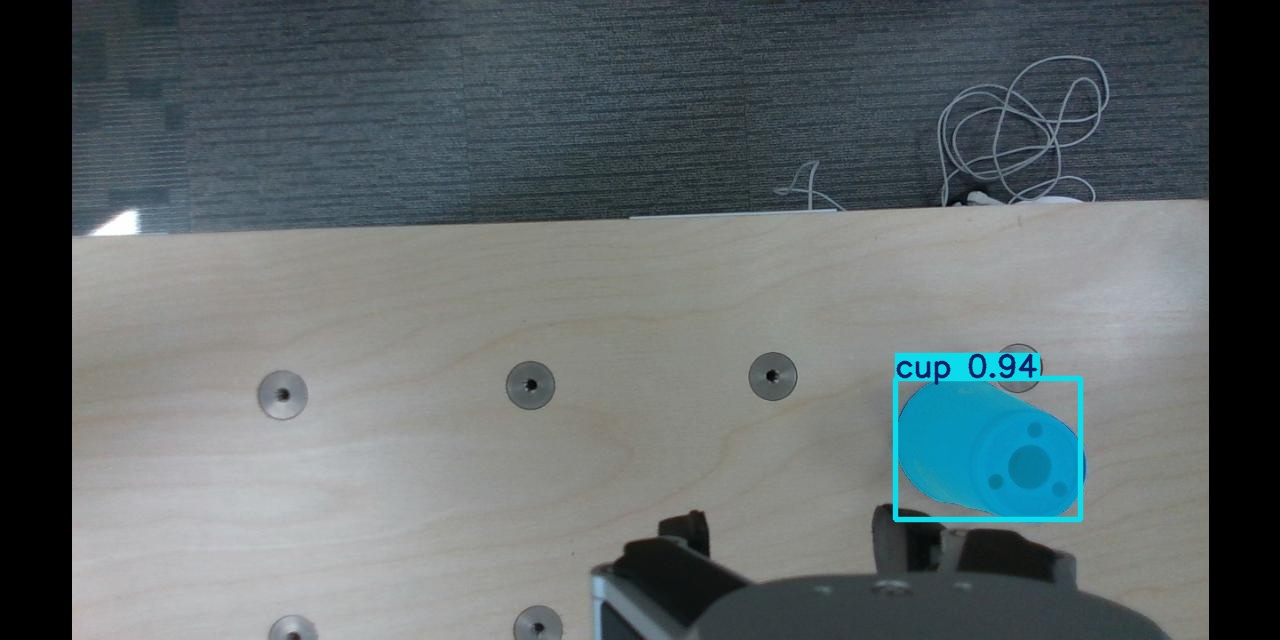

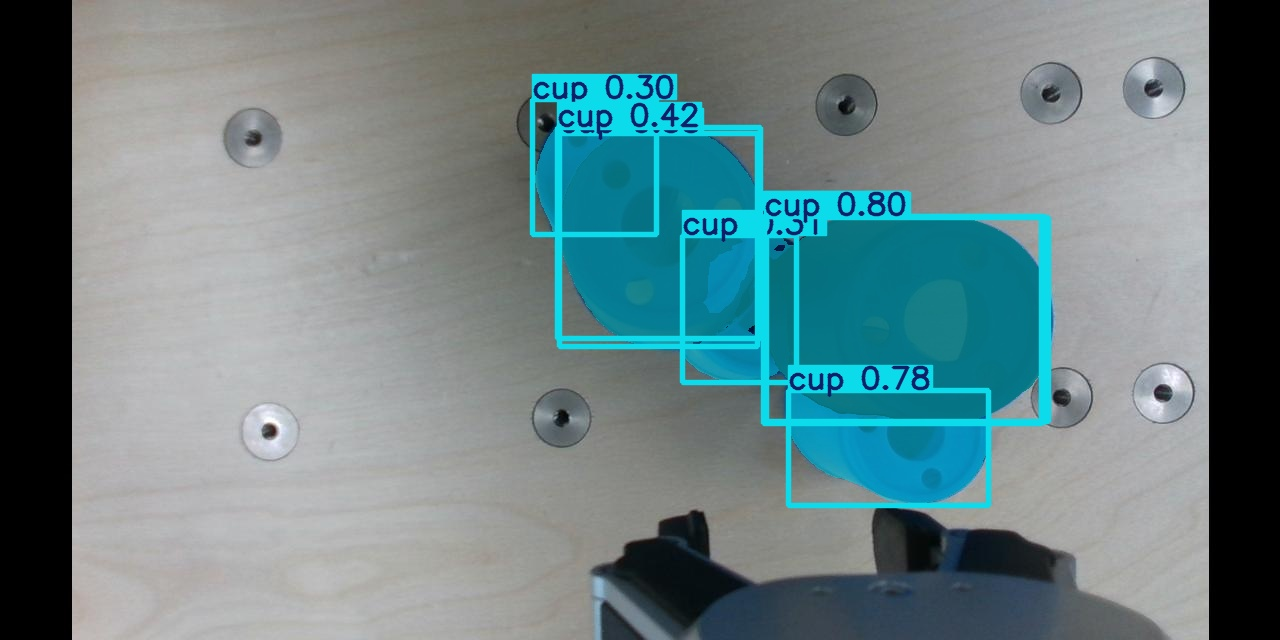

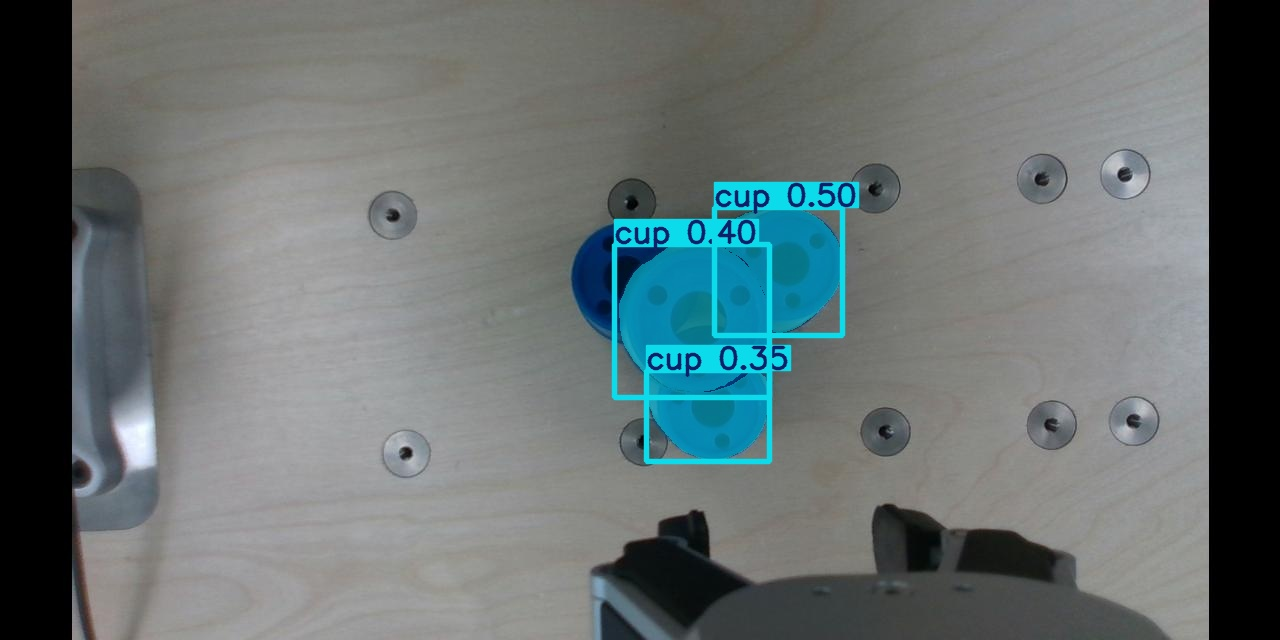

In [ ]:
pred_dir = Path("/content/preds/speed_stack_yolo26_1280_folder")
pred_images = list(pred_dir.glob("*"))

print("result images:", len(pred_images))

for p in pred_images[:5]:
    display(Image(filename=str(p)))